<a href="https://colab.research.google.com/github/luquetabertolini/Checkpoint_2-SERS/blob/main/aula_07_Regressao_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica
Esta atividade faz parte do Checkpoint 2. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna stab, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato .ipynb e faça o upload no repositório GitHub da atividade criado anteriormente. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

# INTEGRANTES
Lucca Bertolini - RM 569552

Raphaello Caffettani - RM 572334

Diego de Oliveira Brandão - RM 569773

Cristhian Henrique Clementino - RM 574117

# 1. Importação das bibliotecas
Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Algoritmo de regressão linear -----> Algoritmo de classificação
from sklearn.linear_model import LinearRegression

# Separação dos dados de treino e teste
# X_train, y_train, X_test, y_test
from sklearn.model_selection import train_test_split

# Métricas de avaliação para regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



# 2. Carregamento e análise inicial do dataset
Carregue o arquivo CSV do conjunto Electrical Grid Stability em um DataFrame chamado df. Depois:

visualize as primeiras linhas;
verifique a quantidade de linhas e colunas;
apresente os nomes e os tipos das colunas;
verifique se existem valores ausentes;
apresente as estatísticas descritivas das variáveis numéricas.

In [100]:
# Carregue o dataset e realize a análise inicial
df = pd.read_csv('https://raw.githubusercontent.com/luquetabertolini/Checkpoint_2-SERS/refs/heads/main/Data_for_UCI_named.csv')
print(df.head())

       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  


In [101]:
# Quantidade de linhas e colunas
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')

Quantidade de linhas: 10000
Quantidade de colunas: 14


In [102]:
# Existem valores ausentes?
print(f'{df.isnull().values.any()}')

False


# 3. Definição da variável target
A variável que os modelos deverão prever é a coluna stab. Crie a variável y com essa coluna e apresente seus primeiros valores.

In [103]:
# Crie a variável y usando a coluna stab
y = df['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


# 4. Matriz de correlação
Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (heatmap). Em seguida, identifique as cinco variáveis com maior correlação absoluta com stab, sem considerar a própria coluna stab.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

In [104]:
# Calcule e visualize a matriz de correlação
matriz_cor = df.select_dtypes(include=np.number).corr()
matriz_cor

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
tau1,1.000000,0.015586,-0.005970,-0.017265,0.027183,-0.015485,-0.015924,-0.015807,0.010521,0.015350,-0.001279,0.005494,0.275761
tau2,0.015586,1.000000,0.014273,-0.001965,-0.004769,0.006573,0.007673,-0.005963,-0.001742,0.015383,0.016508,-0.011764,0.290975
tau3,-0.005970,0.014273,1.000000,0.004354,0.016953,-0.003134,-0.008780,-0.017531,-0.011605,0.007671,0.014702,-0.011497,0.280700
tau4,-0.017265,-0.001965,0.004354,1.000000,-0.003173,0.010553,0.006169,-0.011211,-0.004149,0.008431,0.003260,-0.000491,0.278576
p1,0.027183,-0.004769,0.016953,-0.003173,1.000000,-0.573157,-0.584554,-0.579239,0.000721,0.015405,0.001069,-0.015451,0.010278
p2,-0.015485,0.006573,-0.003134,0.010553,-0.573157,1.000000,0.002388,-0.006844,0.015603,-0.018032,0.007555,0.019817,0.006255
p3,-0.015924,0.007673,-0.008780,0.006169,-0.584554,0.002388,1.000000,0.012953,-0.003219,-0.011575,-0.005897,-0.010485,-0.003321
p4,-0.015807,-0.005963,-0.017531,-0.011211,-0.579239,-0.006844,0.012953,1.000000,-0.013636,0.002850,-0.003515,0.017505,-0.020786
g1,0.010521,-0.001742,-0.011605,-0.004149,0.000721,0.015603,-0.003219,-0.013636,1.000000,0.007559,-0.005836,0.012431,0.282774
g2,0.015350,0.015383,0.007671,0.008431,0.015405,-0.018032,-0.011575,0.002850,0.007559,1.000000,-0.012809,-0.014909,0.293601


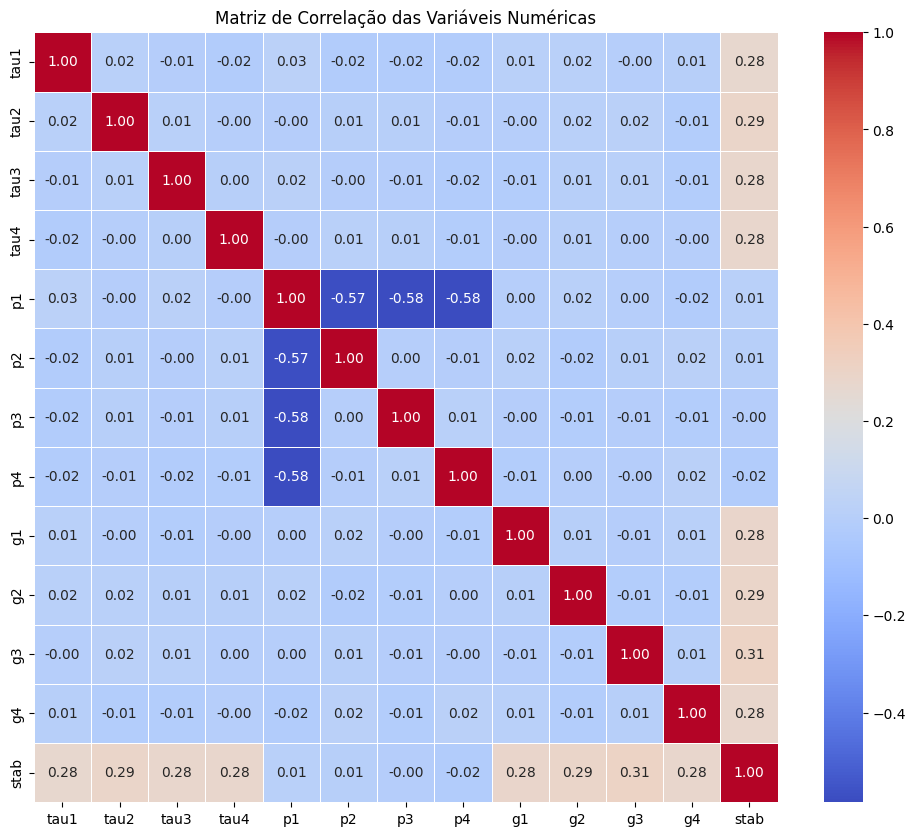

In [105]:
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_cor, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

# 5. Apoio do Gemini para seleção e visualização das variáveis
Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

Tenho um DataFrame Pandas chamado df com dados do Electrical Grid Stability. A variável target é a coluna stab. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com stab; (2) desconsidere a própria coluna stab; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com stab; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada cinco_variaveis; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e stab no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame df já está carregado.


Cinco variáveis com maior correlação absoluta com stab (e seus valores originais de correlação):
g3: 0.3082
g2: 0.2936
tau2: 0.2910
g1: 0.2828
tau3: 0.2807

Lista das cinco variáveis: ['g3', 'g2', 'tau2', 'g1', 'tau3']

Gerando gráficos de dispersão:


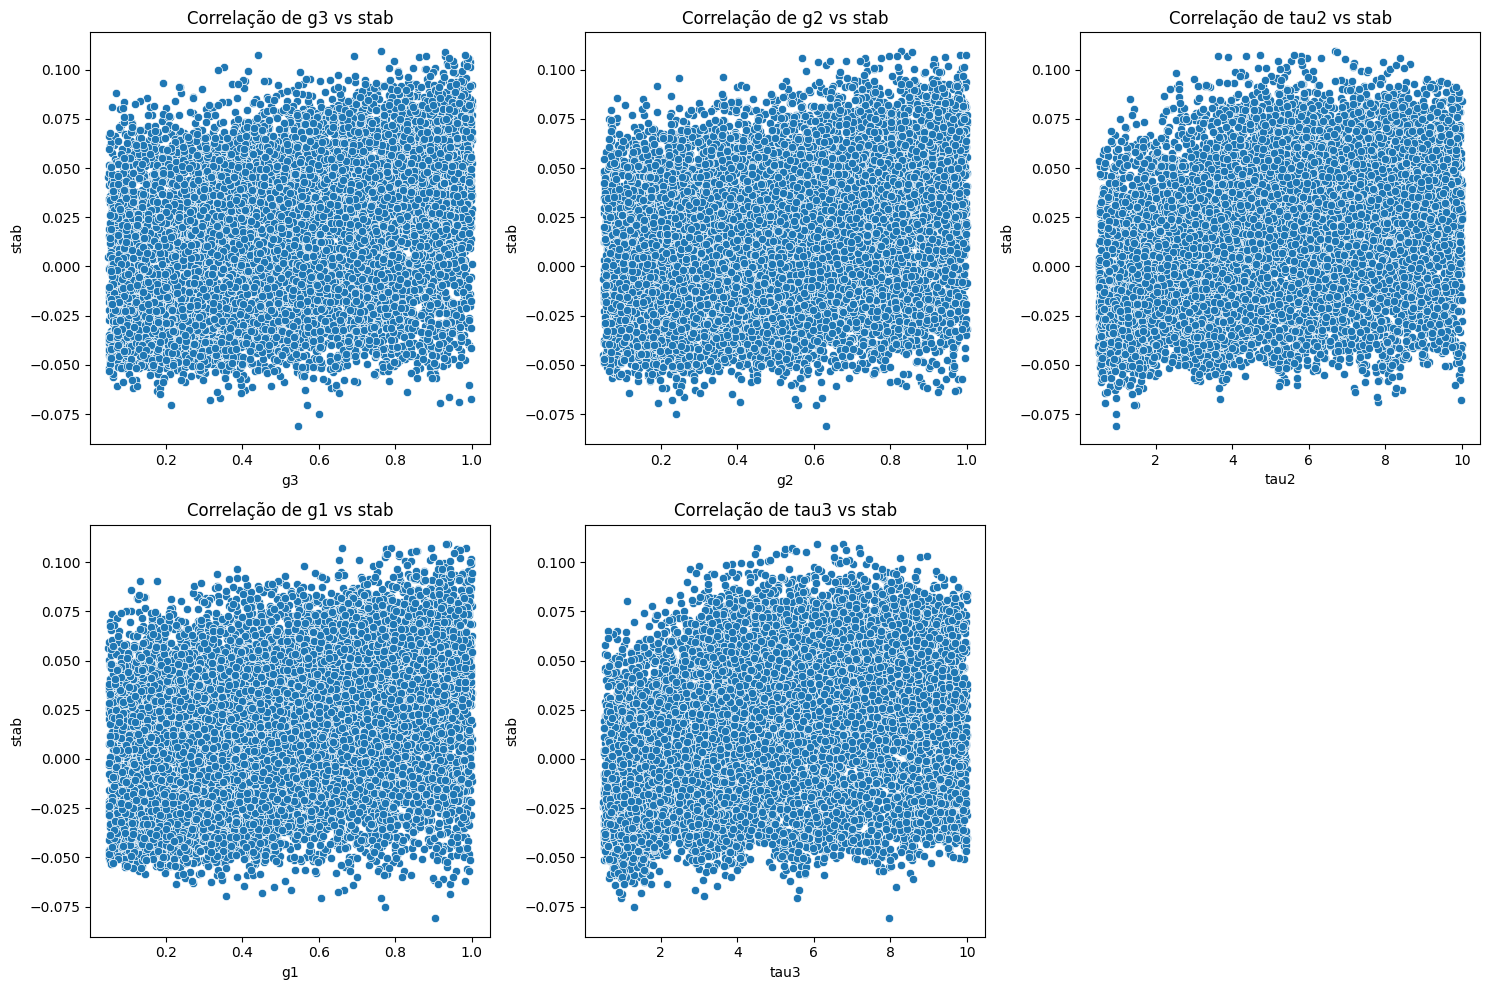

In [106]:
# Calcular a correlação das variáveis numéricas com stab
correlacoes = df.select_dtypes(include=np.number).corrwith(y)

# Desconsiderar a própria variável stab
correlacoes = correlacoes.drop('stab')

# Usar o valor absoluto das correlações para identificar as 5 maiores
absolute_correlations = correlacoes.abs().sort_values(ascending=False)

# Selecionar as 5 variáveis com maior correlação absoluta
top_5_correlations_abs = absolute_correlations.head(5)

print('\nCinco variáveis com maior correlação absoluta com stab (e seus valores originais de correlação):')

for var_name in top_5_correlations_abs.index:
    print(f'{var_name}: {correlacoes[var_name]:.4f}')

# Armazenar os nomes das cinco variáveis em uma lista
cinco_variaveis = top_5_correlations_abs.index.tolist()

print(f'\nLista das cinco variáveis: {cinco_variaveis}')

# Criar cinco gráficos de dispersão
print('\nGerando gráficos de dispersão:')

plt.figure(figsize=(15, 10))

for i, var in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=df[var], y=y)
    plt.title(f'Correlação de {var} vs stab')
    plt.xlabel(var)
    plt.ylabel('stab')

plt.tight_layout()
plt.show()

# **Variáveis selecionadas:**

| Posição | Variável | Correlação original com stab |
|---|---|---|
| 1 | g3 | 0.3082 |
| 2 | g2 | 0.2936 |
| 3 | tau2 | 0.2910 |
| 4 | g1 | 0.2828 |
| 5 | tau3 | 0.2807 |


===========================================================================================

# **1) Qual variável apresentou a maior correlação absoluta com stab?**

Resposta: A variável que apresentou a maior     correlação absoluta com stab foi g3.

===========================================================================================

# **2) O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e stab?**

Resposta: Os gráficos de dispersão indicam que as relações entre as cinco variáveis (g3, g2, tau2, g1, tau3) e stab são fracas e não lineares. Apesar de terem as maiores correlações absolutas entre as variáveis, os pontos nos gráficos estão amplamente dispersos, sem um padrão claro de crescimento ou decrescimento linear. Isso sugere que, embora haja alguma relação, ela não é forte o suficiente para formar uma tendência linear visível, o que é comum em correlações baixas a moderadas. Para variáveis como tau2 e tau3, que são mais contínuas em seus valores, a dispersão é mais aparente. Para as variáveis g (g1, g2, g3) que parecem ter valores mais concentrados, a dispersão também é significativa, indicando que a variação em stab não é bem explicada por essas variáveis de forma isolada.

# Modelo 1 – Cinco maiores correlações
Crie o DataFrame X utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável y deve continuar sendo a coluna stab.

In [107]:
# Crie X com as cinco variáveis selecionadas
# Mostre as primeiras linhas de X e y

X = df[cinco_variaveis]

print("Primeiras linhas de X:")
print(X.head())

print("\nPrimeiras linhas de y:")
print(y.head())

Primeiras linhas de X:
         g3        g2      tau2        g1      tau3
0  0.887445  0.859578  3.079885  0.650456  8.381025
1  0.562139  0.862414  4.902524  0.413441  3.047541
2  0.839444  0.766689  8.848428  0.163041  3.046479
3  0.929381  0.976744  7.669600  0.446209  4.486641
4  0.656947  0.455450  7.608772  0.797110  4.943759

Primeiras linhas de y:
0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64


# 6. Separação entre treino e teste
Separe X e y utilizando 80% dos dados para treinamento e 20% para teste, com random_state=42. Use os nomes X_treino, X_teste, y_treino e y_teste. Apresente a quantidade de registros em cada conjunto.

In [108]:
# Separe os dados de treino e teste do Modelo 1
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Apresente a quantidade de registros em cada conjunto
print(f'Quantidade de registros em X_treino: {len(X_treino)}')
print(f'Quantidade de registros em X_teste: {len(X_teste)}')
print(f'Quantidade de registros em y_treino: {len(y_treino)}')
print(f'Quantidade de registros em y_teste: {len(y_teste)}')

Quantidade de registros em X_treino: 8000
Quantidade de registros em X_teste: 2000
Quantidade de registros em y_treino: 8000
Quantidade de registros em y_teste: 2000


# 7. Treinamento e previsões do Modelo 1
Crie um modelo de Regressão Linear chamado obrigatoriamente modeloLR. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada y_previsao_1.

In [109]:
# Crie e treine modeloLR

modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

# Exiba as primeiras 5 previsões
print("Primeiras 5 previsões (y_previsao_1):")
print(y_previsao_1[:5])

Primeiras 5 previsões (y_previsao_1):
[ 0.0478946   0.03781055 -0.00143381 -0.03422274  0.01228364]


# 8. Métricas do Modelo 1
Calcule R², MAE e MSE. Armazene os resultados nas variáveis r2_modelo_1, mae_modelo_1 e mse_modelo_1. Esses valores serão usados na comparação final.

In [110]:
# Calcule e apresente as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f'R² do Modelo 1: {r2_modelo_1:.4f}')
print(f'MAE do Modelo 1: {mae_modelo_1:.4f}')
print(f'MSE do Modelo 1: {mse_modelo_1:.4f}')

R² do Modelo 1: 0.4018
MAE do Modelo 1: 0.0233
MSE do Modelo 1: 0.0008


# Modelo 2 – Variáveis tau e g
Crie um novo DataFrame chamado X_tau_g contendo todas as colunas cujos nomes começam com tau ou g. Liste as colunas selecionadas para conferir o resultado. A variável target permanece y = df['stab'].

In [111]:
# Selecione todas as colunas iniciadas por tau ou g
colunas_tau_g = [col for col in df.columns if col.startswith('tau') or col.startswith('g')]
X_tau_g = df[colunas_tau_g]

# Liste as colunas selecionadas para conferir o resultado
print('Colunas selecionadas para X_tau_g:')
for col in X_tau_g.columns:
    print(f'- {col}')

print('\nPrimeiras linhas de X_tau_g:')
print(X_tau_g.head())

Colunas selecionadas para X_tau_g:
- tau1
- tau2
- tau3
- tau4
- g1
- g2
- g3
- g4

Primeiras linhas de X_tau_g:
       tau1      tau2      tau3      tau4        g1        g2        g3  \
0  2.959060  3.079885  8.381025  9.780754  0.650456  0.859578  0.887445   
1  9.304097  4.902524  3.047541  1.369357  0.413441  0.862414  0.562139   
2  8.971707  8.848428  3.046479  1.214518  0.163041  0.766689  0.839444   
3  0.716415  7.669600  4.486641  2.340563  0.446209  0.976744  0.929381   
4  3.134112  7.608772  4.943759  9.857573  0.797110  0.455450  0.656947   

         g4  
0  0.958034  
1  0.781760  
2  0.109853  
3  0.362718  
4  0.820923  


# 9. Separação entre treino e teste do Modelo 2
Separe X_tau_g e y usando novamente 80% para treino, 20% para teste e random_state=42. Use os nomes X2_treino, X2_teste, y2_treino e y2_teste.

Manter o mesmo random_state e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [112]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)

# Apresente a quantidade de registros em cada conjunto
print(f'Quantidade de registros em X2_treino: {len(X2_treino)}')
print(f'Quantidade de registros em X2_teste: {len(X2_teste)}')
print(f'Quantidade de registros em y2_treino: {len(y2_treino)}')
print(f'Quantidade de registros em y2_teste: {len(y2_teste)}')


Quantidade de registros em X2_treino: 8000
Quantidade de registros em X2_teste: 2000
Quantidade de registros em y2_treino: 8000
Quantidade de registros em y2_teste: 2000


In [113]:
# Confirme se y_teste e y2_teste possuem os mesmos índices
indices_sao_iguais = y_teste.index.equals(y2_teste.index)
print(f'Os índices de y_teste e y2_teste são iguais: {indices_sao_iguais}')

Os índices de y_teste e y2_teste são iguais: True


# 10. Comparação das métricas dos dois modelos
As métricas devem ser analisadas comparativamente. Crie um único DataFrame chamado comparacao_modelos com uma linha para cada modelo e as colunas Modelo, Variáveis utilizadas, R², MAE e MSE.

Na comparação:

um R² maior indica que o modelo explica uma parcela maior da variação de stab;
um MAE menor indica menor erro absoluto médio;
um MSE menor indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.
Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [114]:
modeloLR_2 = LinearRegression()
modeloLR_2.fit(X2_treino, y2_treino)
y_previsao_2 = modeloLR_2.predict(X2_teste)

r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f'R² do Modelo 2: {r2_modelo_2:.4f}')
print(f'MAE do Modelo 2: {mae_modelo_2:.4f}')
print(f'MSE do Modelo 2: {mse_modelo_2:.4f}')
modelo_1_info = {
    'Modelo': 'Modelo 1',
    'Variáveis utilizadas': ', '.join(cinco_variaveis), # Convert list to string
    'R²': r2_modelo_1,
    'MAE': mae_modelo_1,
    'MSE': mse_modelo_1
}

modelo_2_info = {
    'Modelo': 'Modelo 2',
    'Variáveis utilizadas': ', '.join(colunas_tau_g), # Convert list to string
    'R²': r2_modelo_2,
    'MAE': mae_modelo_2,
    'MSE': mse_modelo_2
}
comparacao_modelos = pd.DataFrame([modelo_1_info, modelo_2_info])
print('\nComparação de Métricas dos Modelos:')
print(comparacao_modelos.round(4))


R² do Modelo 2: 0.6452
MAE do Modelo 2: 0.0176
MSE do Modelo 2: 0.0005

Comparação de Métricas dos Modelos:
     Modelo                    Variáveis utilizadas      R²     MAE     MSE
0  Modelo 1                  g3, g2, tau2, g1, tau3  0.4018  0.0233  0.0008
1  Modelo 2  tau1, tau2, tau3, tau4, g1, g2, g3, g4  0.6452  0.0176  0.0005


# Visualização comparativa
Crie três gráficos de barras lado a lado ou em uma mesma figura:

R² dos dois modelos;
MAE dos dois modelos;
MSE dos dois modelos.
Identifique os modelos e as métricas com títulos e rótulos claros.

/tmp/ipykernel_988/446617480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis')
/tmp/ipykernel_988/446617480.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='magma')
/tmp/ipykernel_988/446617480.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='cividis')


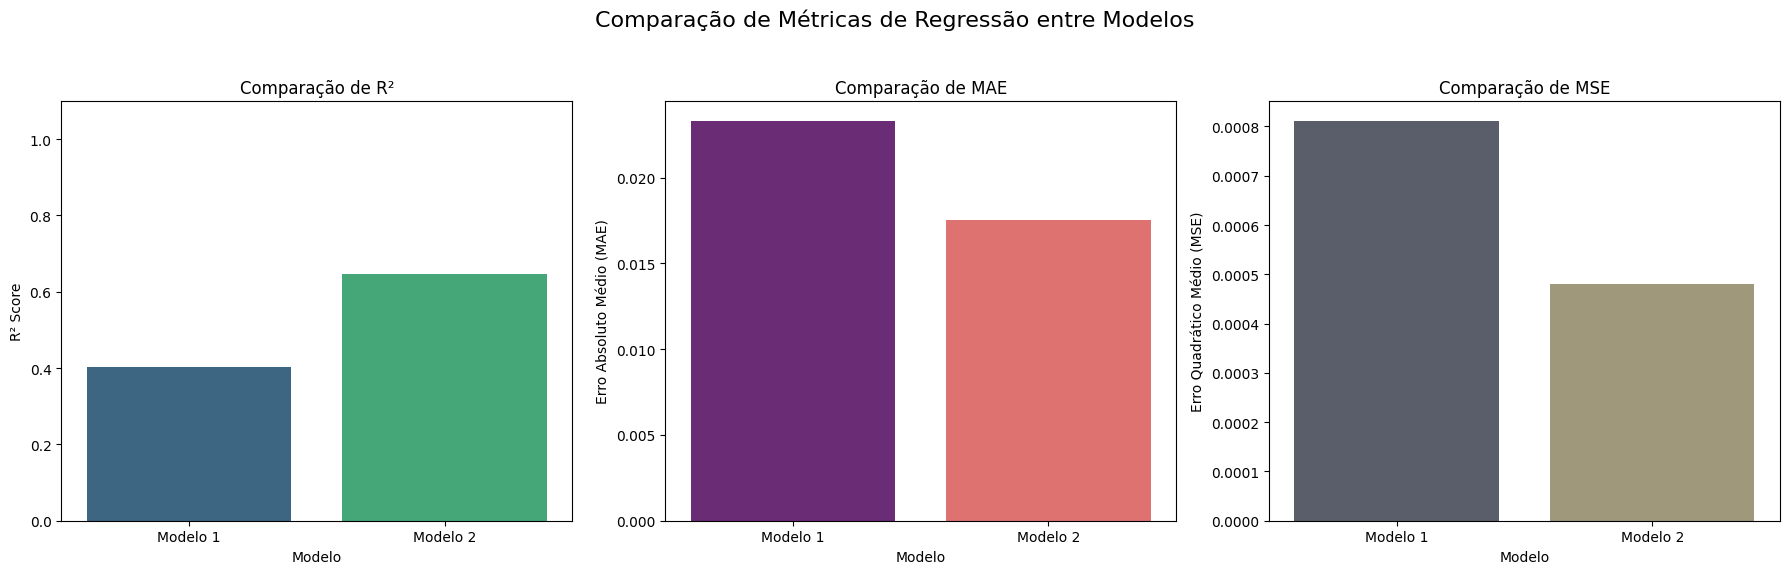

In [115]:
# Crie os gráficos comparativos das métricas

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparação de Métricas de Regressão entre Modelos', fontsize=16)

# R²
sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis')
axes[0].set_title('Comparação de R²')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1) # Set y-limit for R²

# MAE
sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='magma')
axes[1].set_title('Comparação de MAE')
axes[1].set_ylabel('Erro Absoluto Médio (MAE)')

# MSE
sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='cividis')
axes[2].set_title('Comparação de MSE')
axes[2].set_ylabel('Erro Quadrático Médio (MSE)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Análise comparativa final
Responda com base na tabela e nos gráficos comparativos.



1.  **Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**


O Modelo 2 apresentou o maior R², com um valor de 0.6452 O Modelo 1 apresentou um R² de 0.4018.

---

2.  **Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**


O Modelo 2 apresentou o menor MAE, com um valor de 0.0176. O Modelo 1 apresentou um MAE de 0.0233.

---


3.  **Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**


O Modelo 2 apresentou o menor MSE, com um valor de 0.0005 O Modelo 1 apresentou um MSE de 0.0008.

---


4.  **As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**


Sim, as três métricas (R², MAE e MSE) indicaram consistentemente o Modelo 2 como o de melhor desempenho. O Modelo 2 obteve um R² significativamente maior (0.6452 vs 0.4018), o que significa que ele explica uma porcentagem maior da variância da variável `stab`. Além disso, apresentou menores valores de MAE (0.0176 vs 0.0233) e MSE (0.0005 vs 0.0008), indicando que suas previsões são, em média, mais próximas dos valores reais e que ele comete erros quadráticos menores, penalizando menos os erros maiores.

---


5.  **O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis tau e g?**


O desempenho do modelo melhorou consideravelmente ao substituir as cinco variáveis de maior correlação pelo conjunto completo de variáveis `tau` e `g`. O Modelo 1, com as cinco variáveis, teve um R² de 0.4018. O Modelo 2, com o conjunto completo de variáveis `tau` e `g` (que inclui `tau1`, `tau4` e `g4` além das 5 iniciais), alcançou um R² de 0.6452. Essa melhoria sugere que as variáveis adicionais (`tau1`, `tau4` e `g4`), mesmo que individualmente não estivessem entre as cinco mais correlacionadas, contribuíram coletivamente para uma melhor explicação da variância de `stab`, resultando em um modelo mais robusto e com maior poder preditivo.

---


6.  **Considerando os resultados obtidos, qual modelo você escolheria para prever stab? Justifique com R², MAE e MSE.**
Considerando os resultados obtidos, eu escolheria o **Modelo 2** para prever `stab`. Minha justificativa baseia-se nas seguintes métricas:
        *   R² (0.6452): O Modelo 2 explica aproximadamente 64.52% da variância da variável `stab`, o que é consideravelmente superior ao R² de 0.4018 do Modelo 1. Um R² maior indica que o modelo se ajusta melhor aos dados e possui maior poder explicativo.
        *   **MAE (0.0176):** O Erro Absoluto Médio do Modelo 2 é 0.0176, enquanto o do Modelo 1 é 0.0233. Um MAE menor significa que as previsões do Modelo 2 estão, em média, mais próximas dos valores reais, indicando maior precisão.
        *   **MSE (0.0005):** O Erro Quadrático Médio do Modelo 2 é 0.0005, em contraste com 0.0008 do Modelo 1. Um MSE menor e, em particular, mais próximo de zero, sugere que o Modelo 2 não apenas comete erros menores em média, mas também penaliza menos os erros maiores, indicando maior consistência em suas previsões.
    
      Portanto, o Modelo 2 demonstra um desempenho superior e mais confiável em todas as métricas avaliadas.